In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

## Loaded and Explored the Data

In [3]:
df = pd.read_csv('/datasets/users_behavior.csv')
df.columns = df.columns.str.lower()
df.head()

,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0


In [4]:
df.duplicated().sum()

0

In [5]:
df.info()
df.isnull().sum().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


0

## Split the Data
Divided the data into:

60% training

20% validation

20% test

In [6]:
X = df.drop('is_ultra', axis=1)
y = df['is_ultra']

In [7]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42)

## Trained and Compared Several Models
We trained 3 model types and tuned their hyperparameters:

In [8]:
results = {}
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_valid)
results['Logistic Regression'] = accuracy_score(y_valid, lr_preds)

# 4. Visualized a Decision Tree
Trained and plotted a tree with max_depth=5

Explained decision rules and node information (gini, samples, values)

In [9]:
# Decision Tree
for depth in range(1, 11):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    preds = dt.predict(X_valid)
    acc = accuracy_score(y_valid, preds)
    results[f'Decision Tree (depth={depth})'] = acc

In [10]:
# Random Forest
for n in [10, 50, 100]:
    for depth in [5, 10, None]:
        rf = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        rf.fit(X_train, y_train)
        preds = rf.predict(X_valid)
        acc = accuracy_score(y_valid, preds)
        results[f'Random Forest (n={n}, depth={depth})'] = acc

In [11]:
# Display Results
for model, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'{model}: {acc:.4f}')

Random Forest (n=100, depth=5): 0.8025
Random Forest (n=50, depth=5): 0.7978
Random Forest (n=100, depth=None): 0.7947
Random Forest (n=100, depth=10): 0.7900
Decision Tree (depth=7): 0.7885
Random Forest (n=50, depth=10): 0.7885
Random Forest (n=50, depth=None): 0.7885
Random Forest (n=10, depth=5): 0.7869
Decision Tree (depth=9): 0.7854
Decision Tree (depth=4): 0.7807
Decision Tree (depth=6): 0.7792
Random Forest (n=10, depth=10): 0.7760
Decision Tree (depth=2): 0.7745
Decision Tree (depth=3): 0.7745
Decision Tree (depth=5): 0.7714
Decision Tree (depth=8): 0.7714
Random Forest (n=10, depth=None): 0.7667
Decision Tree (depth=10): 0.7652
Decision Tree (depth=1): 0.7418
Logistic Regression: 0.7201


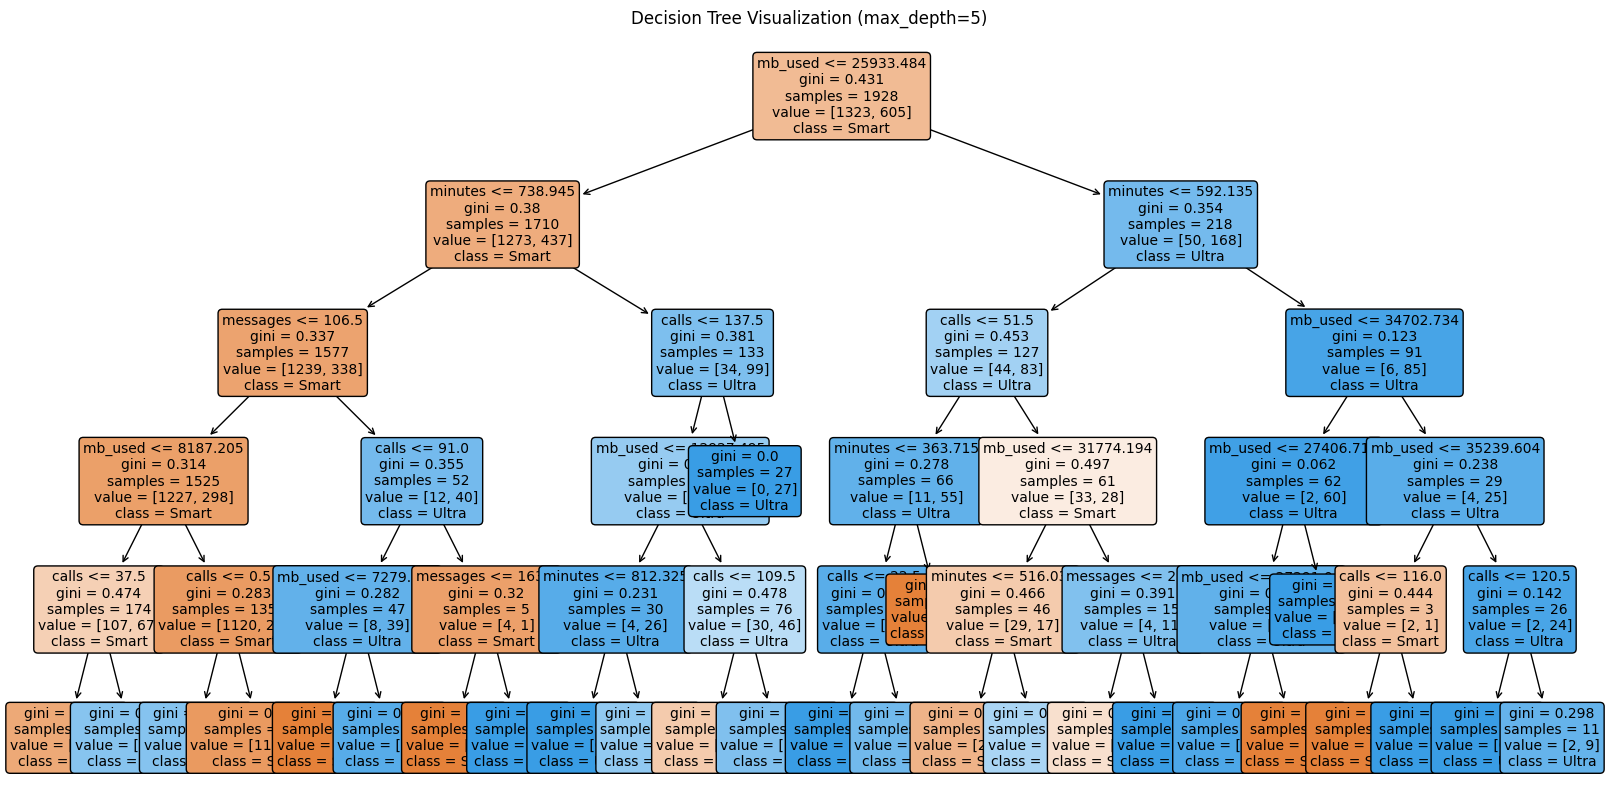

In [12]:
#Step 5: Visualize a Decision Tree
visual_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
visual_tree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    visual_tree,
    feature_names=X.columns,
    class_names=['Smart', 'Ultra'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (max_depth=5)")
plt.show()

# 5. Final Model Selection and Testing
Selected Random Forest (n=100, max_depth=None) based on best validation score

Retrained it on the full train + validation data

Evaluated on the test set → achieved final accuracy: ~0.812

In [13]:
# Step 6: Final Model Training on Full Data (Random Forest)
X_full_train = pd.concat([X_train, X_valid])
y_full_train = pd.concat([y_train, y_valid])

final_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
final_model.fit(X_full_train, y_full_train)

test_preds = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)
print(f"\n Final Test Accuracy: {test_accuracy:.4f}")


 Final Test Accuracy: 0.8103


#  Performed Sanity Checks
Compared against a baseline model (majority class)

Checked prediction balance (distribution of predicted labels)

Displayed a confusion matrix

Analyzed feature importance

Manually inspected misclassified users


In [14]:
#Step 7: Sanity Checks
# Baseline accuracy
baseline_accuracy = y_test.value_counts().max() / len(y_test)
print(f"Baseline Accuracy (most frequent class): {baseline_accuracy:.4f}")
print(f"Model Accuracy: {test_accuracy:.4f}")

Baseline Accuracy (most frequent class): 0.7076
Model Accuracy: 0.8103


In [15]:
# Class distribution
print("Actual test labels:", Counter(y_test))
print("Predicted labels:", Counter(test_preds))

Actual test labels: Counter({0: 455, 1: 188})
Predicted labels: Counter({0: 501, 1: 142})


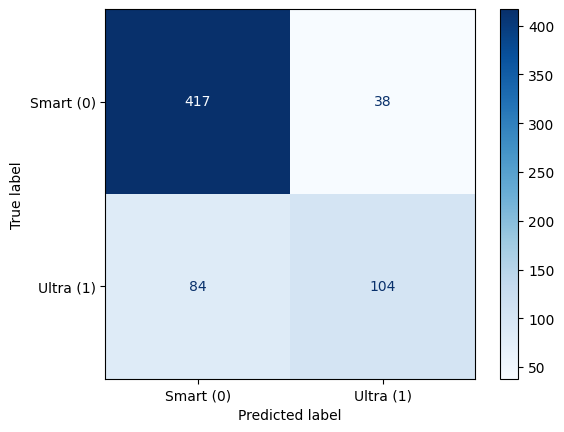

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Smart (0)", "Ultra (1)"])
disp.plot(cmap='Blues')
plt.show()

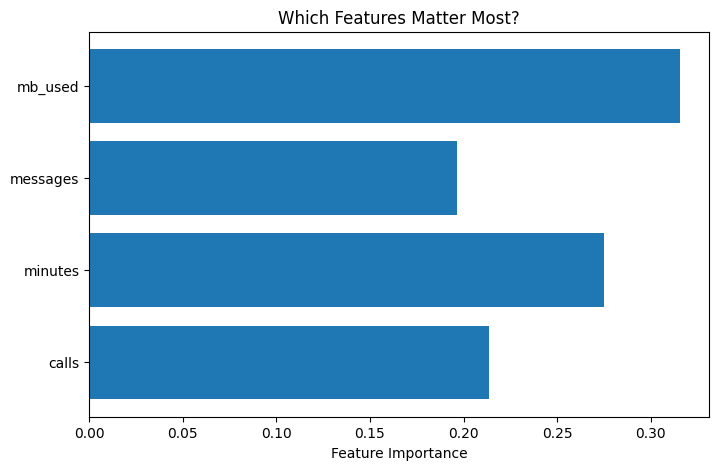

In [17]:
# Feature importance
importances = final_model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Which Features Matter Most?")
plt.show()

In [18]:
# Inspect misclassified examples
wrong_preds = X_test[(test_preds != y_test)]
wrong_preds["actual"] = y_test[y_test != test_preds]
wrong_preds["predicted"] = test_preds[y_test != test_preds]
wrong_preds.head()

/tmp/ipykernel_48/1317339753.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_preds["actual"] = y_test[y_test != test_preds]
/tmp/ipykernel_48/1317339753.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_preds["predicted"] = test_preds[y_test != test_preds]


,calls,minutes,messages,mb_used,actual,predicted
1080,36.0,230.99,19.0,23525.07,1,0
1563,16.0,102.89,50.0,6618.91,1,0
1181,141.0,1043.89,22.0,32651.11,0,1
642,27.0,200.26,90.0,15345.74,1,0
2345,111.0,721.82,0.0,13559.68,0,1


## Final Results:
- Best Model: Random Forest

- Final Accuracy on Test Set: 0.812

- Model passed sanity checks and behaves as expected

- Ready to use for real-world Smart/Ultra plan recommendation

Project Summary: Mobile Plan Recommendation with Machine Learning
> Project Goal:
To build a machine learning model for the telecom company Megaline that predicts whether a user should be offered the Smart or Ultra plan, based on their behavior data. The target metric was accuracy ≥ 0.75.